# 예측 상관 체크 — 모델별 예측이 얼마나 비슷한가

`4_output/` 의 모든 산출물을 **3 그룹**으로 묶어 예측값 간 Pearson 상관 + (그룹 C는) 잔차 상관을 본다. 학습 재실행 없이 csv만 읽음.

| 그룹 | 무엇 | 비교 컬럼 | 소스 |
|---|---|---|---|
| **A — 분류** | Stage 1 분류기의 P(Y>0) | `prob` | `03_two_stage/default/clf/<model>/<exp>/` |
| **B — 회귀 (y>0 조건부)** | Stage 2 회귀기의 E[Y given Y>0] (Y>0 서브셋으로 학습) | `pred` | `03_two_stage/default/reg/<model>/<exp>/` |
| **C — 회귀 (전체 Y)** | zero-inflated Y를 통째로 예측한 최종 모델 | `pred` | `02_reg_single/*`, `01_zit/{zit_only,bag_zit}`, `03_two_stage/reverse`, `03_two_stage/default/combined/*` (clf×reg 곱), `04_stacking/*` |

- 그룹 A·B 끼리는 그룹 C 와 직접 비교 불가 (대상이 다름). 각 그룹 내부 비교 + 보너스로 그룹 간 (분류 prob ↔ 전체 pred).
- `INCLUDE_ALL_EXPS=True` 면 `001`/`002` 등 같은 모델의 여러 실험을 **각각 별도 항목**으로 (재실행 안정성도 같이 보임).


## 1. 환경

In [1]:
import os, sys

# 코드/산출물 zip ID (Colab 전용)
GDRIVE_CODE_ID   = '1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I'   # code.zip = setup.py + utils/
GDRIVE_OUTPUT_ID = '1ts73qEMmjX8cKIb-QeDQ-TMeyudFGWzs'   # 4_output.zip = 산출물 전체

try:
    import google.colab
    if not os.path.exists('/content/project/setup.py'):
        os.system('pip install -q gdown')
        os.system(f'gdown {GDRIVE_CODE_ID} -O /content/code.zip')
        os.system('unzip -qo /content/code.zip -d /content/project')
    if not os.path.exists('/content/project/4_output/01_zit'):
        os.system(f'gdown {GDRIVE_OUTPUT_ID} -O /content/4_output.zip')
        os.system('unzip -qo /content/4_output.zip -d /content/project')
        os.remove('/content/4_output.zip')
    sys.path.insert(0, '/content/project')
    %run /content/project/setup.py
except ImportError:
    %run ../../setup.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from utils.config import KEY_COL, OUTPUT_DIR

# 같은 모델의 모든 실험(001,002,...)을 각각 별도 항목으로 볼지 / 모델당 1개(OOF best)만 볼지
INCLUDE_ALL_EXPS          = True
# combined의 position-weighted 버전(*_unit_weighted.csv)도 별도 항목으로 추가할지
INCLUDE_WEIGHTED_COMBINED = False

print(f'OUTPUT_DIR = {OUTPUT_DIR}')
print(f'INCLUDE_ALL_EXPS={INCLUDE_ALL_EXPS}  INCLUDE_WEIGHTED_COMBINED={INCLUDE_WEIGHTED_COMBINED}')


setup 완료
OUTPUT_DIR = c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output
INCLUDE_ALL_EXPS=True  INCLUDE_WEIGHTED_COMBINED=False


## 2. 예측 소스 자동 탐지 (3 그룹)

각 항목 = `(label, dir, value_col)`. `label` 은 그룹 내 고유 이름. `value_col` 은 상관 계산에 쓸 컬럼. (`pred|weighted` 처럼 `|` 뒤 마커가 붙으면 특수 파일을 가리킴 — 4번 셀 `_read_unit` 참조)

In [2]:
# --- 실험폴더 헬퍼 ------------------------------------------------------------
REQ = ['oof_unit.csv', 'val_unit.csv', 'test_unit.csv']

def _oof_metric(exp_dir, value_col):
    # OOF 성능 (낮을수록 좋게 정규화) — pred: RMSE, prob: -AUC. INCLUDE_ALL_EXPS=False 일 때 best 실험 고르는 데만 사용
    p = os.path.join(exp_dir, 'oof_unit.csv')
    if not os.path.exists(p): return None
    df = pd.read_csv(p)
    if 'health' not in df.columns or value_col not in df.columns: return None
    d = df.dropna(subset=[value_col, 'health'])
    if len(d) == 0: return None
    if value_col == 'prob':
        try:
            from sklearn.metrics import roc_auc_score
            return -float(roc_auc_score((d['health'].values > 0).astype(int), d[value_col].values))
        except Exception:
            return None
    return float(np.sqrt(np.mean((d[value_col].values - d['health'].values) ** 2)))

def _exps_under(model_dir, value_col):
    # model_dir 바로 아래 REQ 있으면 [('', model_dir)], 아니면 숫자 하위폴더들 [(exp, path), ...]
    if not os.path.isdir(model_dir): return []
    if all(os.path.exists(os.path.join(model_dir, f)) for f in REQ):
        return [('', model_dir)]
    found = []
    for d in sorted(os.listdir(model_dir)):
        sub = os.path.join(model_dir, d)
        if d.isdigit() and os.path.isdir(sub) and all(os.path.exists(os.path.join(sub, f)) for f in REQ):
            found.append((d, sub))
    if not found:
        return []
    if INCLUDE_ALL_EXPS:
        return found
    scored = [(e, p, _oof_metric(p, value_col)) for e, p in found]
    sc = [t for t in scored if t[2] is not None]
    if sc:
        best = min(sc, key=lambda t: t[2])
        return [(best[0], best[1])]
    return [max(found, key=lambda t: t[0])]

def _add_model_family(items, root, value_col, label_prefix):
    # root 아래 각 모델 폴더 → 실험별 항목 추가
    if not os.path.isdir(root): return
    for name in sorted(os.listdir(root)):
        mdir = os.path.join(root, name)
        if not os.path.isdir(mdir): continue
        for exp, path in _exps_under(mdir, value_col):
            lbl = f'{label_prefix}:{name}' + (f':{exp}' if exp else '')
            items.append((lbl, path, value_col))

# --- 그룹 A: 분류 (P(Y>0)) ---------------------------------------------------
GROUP_A = []
_add_model_family(GROUP_A, os.path.join(OUTPUT_DIR, '03_two_stage', 'default', 'clf'), 'prob', 'clf')

# --- 그룹 B: 회귀 (y>0 조건부, E[Y|Y>0]) ------------------------------------
GROUP_B = []
_add_model_family(GROUP_B, os.path.join(OUTPUT_DIR, '03_two_stage', 'default', 'reg'), 'pred', 'cond')

# --- 그룹 C: 회귀 (전체 Y) --------------------------------------------------
GROUP_C = []
_add_model_family(GROUP_C, os.path.join(OUTPUT_DIR, '02_reg_single'), 'pred', 'full')
for fam in ['zit_only', 'bag_zit']:
    for exp, path in _exps_under(os.path.join(OUTPUT_DIR, '01_zit', fam), 'pred'):
        GROUP_C.append((f'zit:{fam}' + (f':{exp}' if exp else ''), path, 'pred'))
for exp, path in _exps_under(os.path.join(OUTPUT_DIR, '03_two_stage', 'reverse'), 'pred'):
    GROUP_C.append(('rev' + (f':{exp}' if exp else ''), path, 'pred'))
# combined: clf×reg 곱 (mean 집계본). weighted 도 옵션
_cd = os.path.join(OUTPUT_DIR, '03_two_stage', 'default', 'combined')
if os.path.isdir(_cd):
    for combo in sorted(os.listdir(_cd)):
        cdir = os.path.join(_cd, combo)
        if os.path.isdir(cdir) and os.path.exists(os.path.join(cdir, 'oof_unit.csv')):
            GROUP_C.append((f'combo:{combo}', cdir, 'pred'))
            if INCLUDE_WEIGHTED_COMBINED and os.path.exists(os.path.join(cdir, 'oof_unit_weighted.csv')):
                GROUP_C.append((f'comboW:{combo}', cdir, 'pred|weighted'))
# stacking: 각 tag의 stack / blend
_sd = os.path.join(OUTPUT_DIR, '04_stacking')
if os.path.isdir(_sd):
    for tag in sorted(os.listdir(_sd)):
        tdir = os.path.join(_sd, tag)
        if not os.path.isdir(tdir): continue
        if os.path.exists(os.path.join(tdir, 'oof_unit_stack.csv')):
            GROUP_C.append((f'stack:{tag}', tdir, 'pred|stack'))
        if os.path.exists(os.path.join(tdir, 'oof_unit_blend.csv')):
            GROUP_C.append((f'blend:{tag}', tdir, 'pred|blend'))

for gname, g in [('A 분류 (prob)', GROUP_A), ('B 회귀·y>0조건부 (pred)', GROUP_B), ('C 회귀·전체 (pred)', GROUP_C)]:
    print(f'\n=== 그룹 {gname} — {len(g)}개 ===')
    for lbl, path, vc in g:
        print(f'  {lbl:32s}  {os.path.relpath(path, OUTPUT_DIR)}  [{vc}]')



=== 그룹 A 분류 (prob) — 8개 ===
  clf:catboost:001                  03_two_stage\default\clf\catboost\001  [prob]
  clf:catboost:002                  03_two_stage\default\clf\catboost\002  [prob]
  clf:et:001                        03_two_stage\default\clf\et\001  [prob]
  clf:et:002                        03_two_stage\default\clf\et\002  [prob]
  clf:lgbm:001                      03_two_stage\default\clf\lgbm\001  [prob]
  clf:lgbm:002                      03_two_stage\default\clf\lgbm\002  [prob]
  clf:xgb:001                       03_two_stage\default\clf\xgb\001  [prob]
  clf:xgb:002                       03_two_stage\default\clf\xgb\002  [prob]

=== 그룹 B 회귀·y>0조건부 (pred) — 9개 ===
  cond:catboost:001                 03_two_stage\default\reg\catboost\001  [pred]
  cond:catboost:002                 03_two_stage\default\reg\catboost\002  [pred]
  cond:enet:001                     03_two_stage\default\reg\enet\001  [pred]
  cond:et:001                       03_two_stage\default\reg\et\001

## 3. 공통 함수 — 로드 / 상관행렬 / 히트맵 / 극단 페어

In [3]:
def _read_unit(path, value_col, split):
    # value_col 이 'pred|weighted' 처럼 마커가 붙으면 해당 파일/컬럼을 읽음
    if '|' in value_col:
        _, kind = value_col.split('|', 1)
        fname = {'weighted': f'{split}_unit_weighted.csv',
                 'stack':    f'{split}_unit_stack.csv',
                 'blend':    f'{split}_unit_blend.csv'}[kind]
        col = 'pred'
    else:
        fname, col = f'{split}_unit.csv', value_col
    df = pd.read_csv(os.path.join(path, fname))
    return df.set_index(KEY_COL)[[col, 'health']].rename(columns={col: 'v'})

def load_group(group, split):
    # group(list of (label,path,vc)) → (P: DataFrame[label]=pred, y: Series[health])
    series, y = {}, None
    for lbl, path, vc in group:
        d = _read_unit(path, vc, split)
        series[lbl] = d['v']
        if y is None:
            y = d['health']
    P = pd.DataFrame(series)
    P = P.loc[sorted(P.index)]
    y = y.reindex(P.index)
    return P, y

def _offdiag(C):
    v = C.values[np.triu_indices_from(C.values, k=1)]
    return v[~np.isnan(v)]

def corr_report(C, title):
    v = _offdiag(C)
    if len(v) == 0:
        print(f'[{title}] 페어 없음 (항목 {C.shape[0]}개)'); return
    print(f'[{title}]  항목 {C.shape[0]}개 · 페어 {len(v)}개')
    print(f'  상관: min={v.min():.4f}  mean={v.mean():.4f}  median={np.median(v):.4f}  max={v.max():.4f}')
    print(f'  <0.80: {(v<0.80).sum()} | <0.90: {(v<0.90).sum()} | <0.95: {(v<0.95).sum()} | <0.99: {(v<0.99).sum()}  (/{len(v)})')

def pair_extremes(C, k=8):
    A = C.values.copy(); np.fill_diagonal(A, np.nan)
    iu = np.triu_indices_from(A, k=1)
    vv = A[iu]
    mask = ~np.isnan(vv); vv, ii, jj = vv[mask], iu[0][mask], iu[1][mask]
    if len(vv) == 0:
        return
    order = np.argsort(vv)
    names = list(C.columns)
    print(f'  ↓ 가장 낮은 {min(k,len(order))}쌍 (가장 다른 예측):')
    for t in order[:k]:
        print(f'    {names[ii[t]]:30s} ~ {names[jj[t]]:30s} = {vv[t]:.4f}')
    print(f'  ↑ 가장 높은 {min(k,len(order))}쌍 (사실상 같은 예측):')
    for t in order[-k:][::-1]:
        print(f'    {names[ii[t]]:30s} ~ {names[jj[t]]:30s} = {vv[t]:.4f}')

def _cluster_order(C):
    # |1-corr| 거리로 계층군집 → 비슷한 것끼리 인접하게 컬럼 재정렬 (scipy 없으면 원순서)
    try:
        from scipy.cluster.hierarchy import linkage, leaves_list
        from scipy.spatial.distance import squareform
        D = 1.0 - C.abs().values
        np.fill_diagonal(D, 0.0)
        D = (D + D.T) / 2
        Z = linkage(squareform(D, checks=False), method='average')
        return [C.columns[i] for i in leaves_list(Z)]
    except Exception:
        return list(C.columns)

def plot_heatmap(C, title, cluster=True, figsize=None):
    cols = _cluster_order(C) if cluster else list(C.columns)
    M = C.loc[cols, cols]
    n = len(cols)
    figsize = figsize or (max(6, n * 0.42 + 2), max(5, n * 0.42 + 1.5))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(M.values, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(n)); ax.set_xticklabels(cols, rotation=90, fontsize=7)
    ax.set_yticks(range(n)); ax.set_yticklabels(cols, fontsize=7)
    if n <= 18:
        for i in range(n):
            for j in range(n):
                ax.text(j, i, f'{M.values[i,j]:.2f}', ha='center', va='center',
                        fontsize=6, color='white' if abs(M.values[i,j]) > 0.6 else 'black')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    plt.tight_layout(); plt.show()

def rmse(p, y):
    p = np.asarray(p, float); y = np.asarray(y, float)
    m = ~(np.isnan(p) | np.isnan(y))
    return float(np.sqrt(np.mean((p[m] - y[m]) ** 2)))


## 4. 그룹 A — 분류 `P(Y>0)`

분류기들의 확률 예측이 서로 얼마나 닮았는지. (RMSE 가 아니라 **AUC** 로 성능 표시)

=== 그룹 A — AUC (val 내림차순) ===
           model    oof    val   test
     clf:xgb:001 0.6665 0.6727 0.6789
     clf:xgb:002 0.6653 0.6720 0.6777
    clf:lgbm:002 0.6651 0.6718 0.6774
    clf:lgbm:001 0.6658 0.6715 0.6771
clf:catboost:001 0.6653 0.6707 0.6791
clf:catboost:002 0.6643 0.6705 0.6780
      clf:et:002 0.6629 0.6651 0.6701
      clf:et:001 0.6437 0.6422 0.6493

----- 그룹 A · OOF : prob 상관 -----
[A/oof]  항목 8개 · 페어 28개
  상관: min=0.8344  mean=0.9438  median=0.9650  max=0.9954
  <0.80: 0 | <0.90: 6 | <0.95: 12 | <0.99: 23  (/28)
  ↓ 가장 낮은 6쌍 (가장 다른 예측):
    clf:et:001                     ~ clf:lgbm:002                   = 0.8344
    clf:et:001                     ~ clf:lgbm:001                   = 0.8367
    clf:et:001                     ~ clf:xgb:001                    = 0.8543
    clf:et:001                     ~ clf:xgb:002                    = 0.8571
    clf:catboost:001               ~ clf:et:001                     = 0.8668
    clf:catboost:002               ~ clf:et:001   

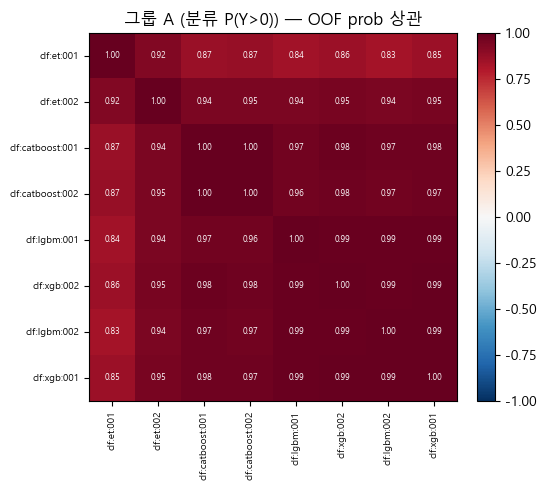


----- 그룹 A · VAL : prob 상관 -----
[A/val]  항목 8개 · 페어 28개
  상관: min=0.8409  mean=0.9497  median=0.9728  max=0.9977
  <0.80: 0 | <0.90: 6 | <0.95: 9 | <0.99: 21  (/28)
  ↓ 가장 낮은 6쌍 (가장 다른 예측):
    clf:et:001                     ~ clf:lgbm:002                   = 0.8409
    clf:et:001                     ~ clf:lgbm:001                   = 0.8443
    clf:et:001                     ~ clf:xgb:001                    = 0.8605
    clf:et:001                     ~ clf:xgb:002                    = 0.8642
    clf:catboost:001               ~ clf:et:001                     = 0.8744
    clf:catboost:002               ~ clf:et:001                     = 0.8809
  ↑ 가장 높은 6쌍 (사실상 같은 예측):
    clf:catboost:001               ~ clf:catboost:002               = 0.9977
    clf:xgb:001                    ~ clf:xgb:002                    = 0.9966
    clf:lgbm:002                   ~ clf:xgb:001                    = 0.9961
    clf:lgbm:001                   ~ clf:xgb:001                    = 0.9953
    clf:lgbm

In [4]:
if not GROUP_A:
    print('그룹 A 항목 없음 — 03_two_stage/default/clf/ 산출물 확인')
else:
    from sklearn.metrics import roc_auc_score
    rows = []
    for lbl, path, vc in GROUP_A:
        r = {'model': lbl}
        for sp in ['oof', 'val', 'test']:
            d = _read_unit(path, vc, sp).dropna()
            r[sp] = float(roc_auc_score((d['health'].values > 0).astype(int), d['v'].values))
        rows.append(r)
    print('=== 그룹 A — AUC (val 내림차순) ===')
    print(pd.DataFrame(rows).sort_values('val', ascending=False).to_string(index=False, float_format='%.4f'))

    for sp in ['oof', 'val', 'test']:
        P, y = load_group(GROUP_A, sp)
        C = P.corr()
        print(f'\n----- 그룹 A · {sp.upper()} : prob 상관 -----')
        corr_report(C, f'A/{sp}'); pair_extremes(C, k=6)
        if sp == 'oof':
            plot_heatmap(C, '그룹 A (분류 P(Y>0)) — OOF prob 상관')


## 5. 그룹 B — 회귀 (y>0 조건부) `E[Y|Y>0]`

Y>0 서브셋으로 학습한 회귀기들. 예측은 전 unit에 대해 나오지만(곱셈용), 상관은 전체 unit 기준. 성능은 **Y>0 unit 만** 대상으로 한 RMSE.

=== 그룹 B — RMSE (Y>0 unit 한정, val 오름차순) ===
            model  oof·Y>0  val·Y>0  test·Y>0
      cond:et:001 0.007504 0.007981  0.013824
      cond:et:002 0.007502 0.007982  0.013823
    cond:enet:001 0.007791 0.008247  0.014003
cond:catboost:001 0.007872 0.008280  0.014043
cond:catboost:002 0.007904 0.008306  0.014050
    cond:lgbm:001 0.007900 0.008323  0.014084
    cond:lgbm:002 0.007905 0.008325  0.014089
     cond:xgb:001 0.007906 0.008357  0.014109
     cond:xgb:002 0.007908 0.008357  0.014114

----- 그룹 B · OOF : pred 상관 (전체 unit) -----
[B/oof]  항목 9개 · 페어 36개
  상관: min=0.2716  mean=0.5098  median=0.4427  max=0.9634
  <0.80: 33 | <0.90: 34 | <0.95: 35 | <0.99: 36  (/36)
  ↓ 가장 낮은 6쌍 (가장 다른 예측):
    cond:catboost:002              ~ cond:et:002                    = 0.2716
    cond:catboost:002              ~ cond:enet:001                  = 0.2766
    cond:et:002                    ~ cond:xgb:002                   = 0.2907
    cond:et:002                    ~ cond:xgb:001           

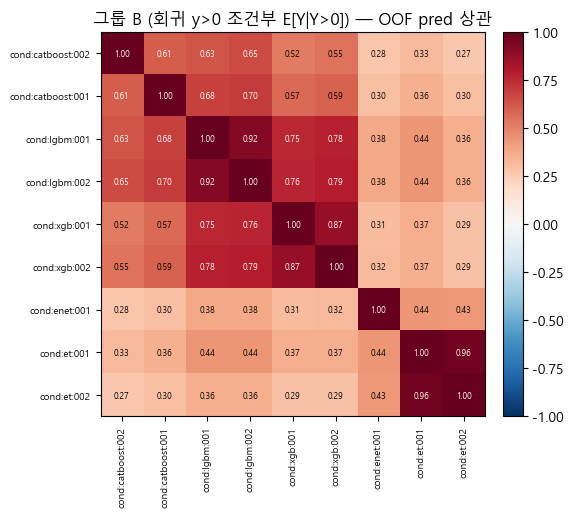


----- 그룹 B · VAL : pred 상관 (전체 unit) -----
[B/val]  항목 9개 · 페어 36개
  상관: min=0.3026  mean=0.5652  median=0.4724  max=0.9773
  <0.80: 27 | <0.90: 33 | <0.95: 33 | <0.99: 36  (/36)
  ↓ 가장 낮은 6쌍 (가장 다른 예측):
    cond:et:002                    ~ cond:xgb:002                   = 0.3026
    cond:catboost:002              ~ cond:enet:001                  = 0.3097
    cond:et:002                    ~ cond:xgb:001                   = 0.3123
    cond:catboost:002              ~ cond:et:002                    = 0.3186
    cond:enet:001                  ~ cond:xgb:001                   = 0.3385
    cond:enet:001                  ~ cond:xgb:002                   = 0.3420
  ↑ 가장 높은 6쌍 (사실상 같은 예측):
    cond:et:001                    ~ cond:et:002                    = 0.9773
    cond:lgbm:001                  ~ cond:lgbm:002                  = 0.9744
    cond:xgb:001                   ~ cond:xgb:002                   = 0.9626
    cond:lgbm:002                  ~ cond:xgb:002                   = 0.8342

In [5]:
if not GROUP_B:
    print('그룹 B 항목 없음 — 03_two_stage/default/reg/ 산출물 확인')
else:
    rows = []
    for lbl, path, vc in GROUP_B:
        r = {'model': lbl}
        for sp in ['oof', 'val', 'test']:
            d = _read_unit(path, vc, sp).dropna()
            pos = d[d['health'] > 0]
            r[f'{sp}·Y>0'] = rmse(pos['v'], pos['health'])
        rows.append(r)
    print('=== 그룹 B — RMSE (Y>0 unit 한정, val 오름차순) ===')
    print(pd.DataFrame(rows).sort_values('val·Y>0').to_string(index=False, float_format='%.6f'))

    for sp in ['oof', 'val', 'test']:
        P, y = load_group(GROUP_B, sp)
        C = P.corr()
        print(f'\n----- 그룹 B · {sp.upper()} : pred 상관 (전체 unit) -----')
        corr_report(C, f'B/{sp}'); pair_extremes(C, k=6)
        if sp == 'oof':
            plot_heatmap(C, '그룹 B (회귀 y>0 조건부 E[Y|Y>0]) — OOF pred 상관')


## 6. 그룹 C — 회귀 (전체 Y)

같은 target(zero-inflated Y)을 예측하는 모든 최종 모델: `reg_single`, ZIT(`zit_only`/`bag_zit`), reverse two-stage, two-stage 곱(`combined/*`), stacking(`stack`/`blend`). 예측 상관 + **잔차 상관**(앙상블에 진짜 중요한 지표) 둘 다.

=== 그룹 C — RMSE (전체 unit, val 오름차순, 34개) ===
                    model      oof      val     test
            stack:curated 0.005489 0.005701 0.008408
               stack:base 0.005493 0.005704 0.008410
         zit:zit_only:001 0.005497 0.005704 0.008411
          zit:bag_zit:001 0.005499 0.005705 0.008409
                  rev:001 0.005497 0.005706 0.008412
               blend:base 0.005496 0.005707 0.008412
          combo:lgbm_x_et 0.008243 0.005709 0.008413
           combo:xgb_x_et 0.008242 0.005710 0.008414
      combo:catboost_x_et 0.008246 0.005714 0.008416
            combo:et_x_et 0.008246 0.005721 0.008422
            full:lgbm:002 0.005509 0.005722 0.008428
            full:lgbm:001 0.005518 0.005726 0.008427
             full:xgb:001 0.005526 0.005728 0.008423
        full:catboost:001 0.005522 0.005730 0.008429
        full:catboost:002 0.005523 0.005733 0.008432
              full:et:002 0.005520 0.005734 0.008433
              full:et:001 0.005540 0.005755 0.008450
 

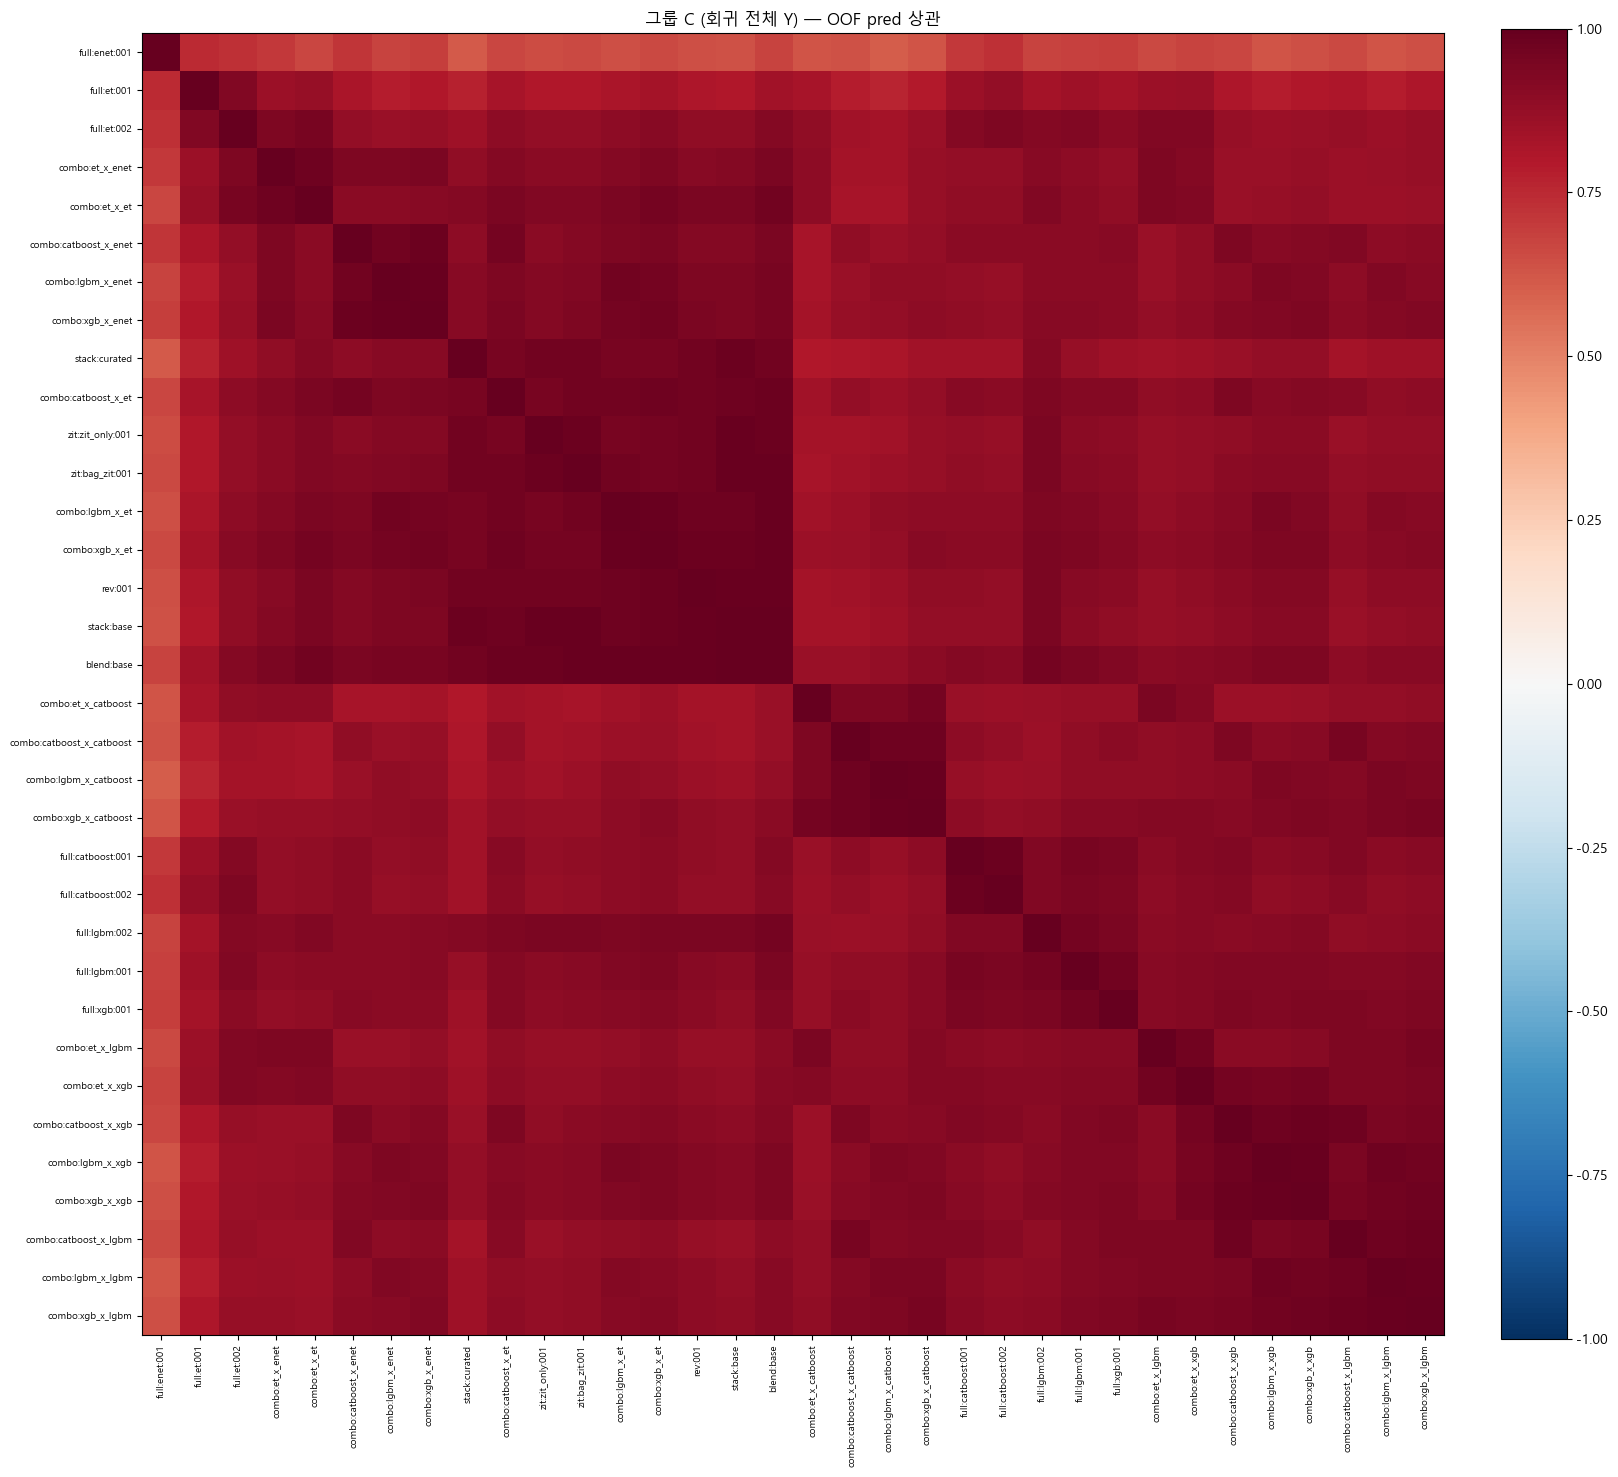


----- 그룹 C · OOF : 잔차(pred-health) 상관 -----
[C/oof (residual)]  항목 34개 · 페어 561개
  상관: min=0.9873  mean=0.9962  median=0.9965  max=0.9999
  <0.80: 0 | <0.90: 0 | <0.95: 0 | <0.99: 10  (/561)
  ↓ 가장 낮은 8쌍 (가장 다른 예측):
    full:enet:001                  ~ zit:bag_zit:001                = 0.9873
    full:enet:001                  ~ rev:001                        = 0.9874
    full:enet:001                  ~ stack:curated                  = 0.9876
    full:enet:001                  ~ combo:catboost_x_et            = 0.9880
    full:enet:001                  ~ zit:zit_only:001               = 0.9880
    full:enet:001                  ~ full:xgb:001                   = 0.9889
    full:enet:001                  ~ combo:lgbm_x_et                = 0.9889
    full:enet:001                  ~ stack:base                     = 0.9890
  ↑ 가장 높은 8쌍 (사실상 같은 예측):
    combo:lgbm_x_xgb               ~ combo:xgb_x_xgb                = 0.9999
    combo:lgbm_x_lgbm              ~ combo:xgb_x_lgbm           

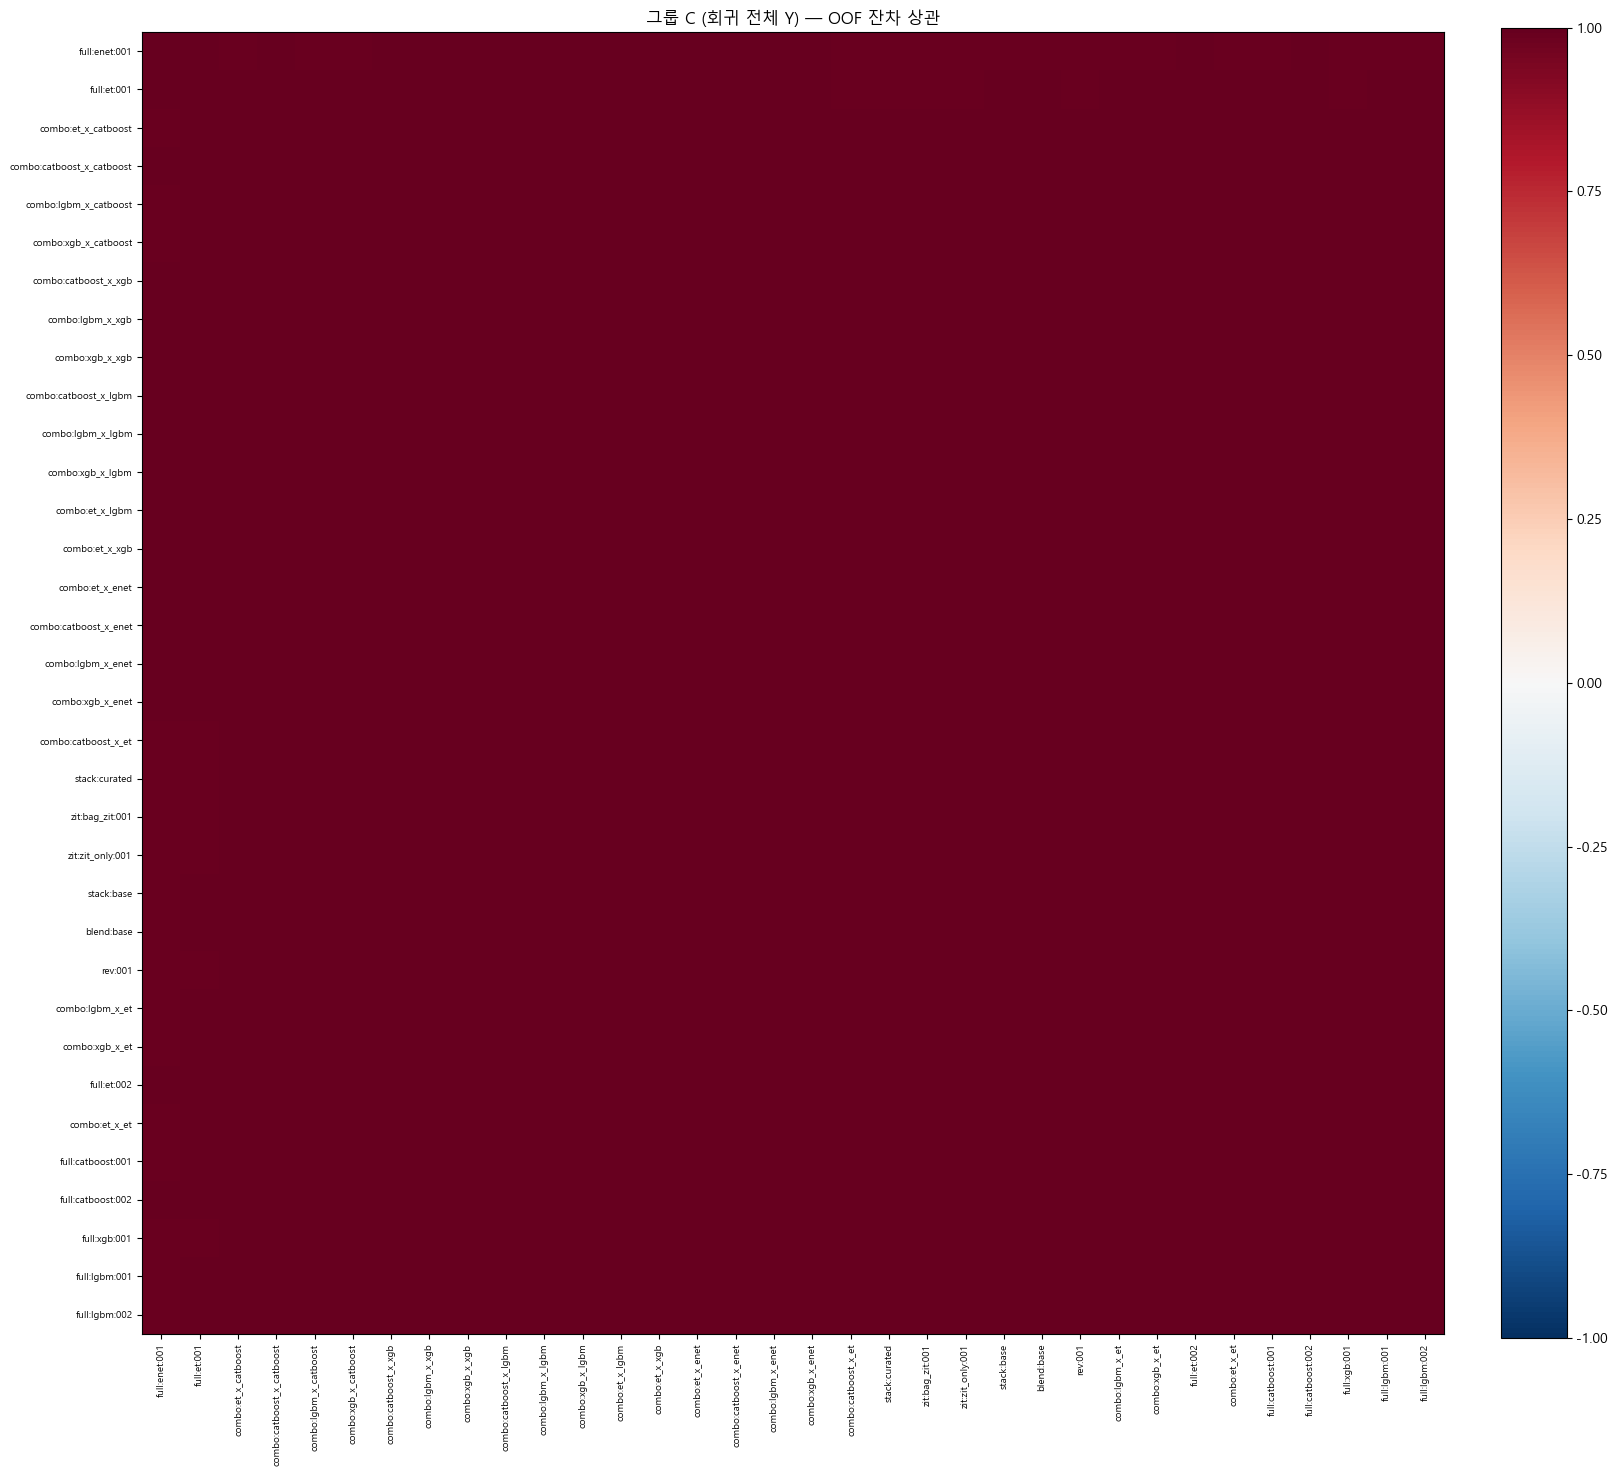


----- 그룹 C · VAL : pred 상관 -----
[C/val (pred)]  항목 34개 · 페어 561개
  상관: min=0.6366  mean=0.9080  median=0.9221  max=0.9960
  <0.80: 36 | <0.90: 167 | <0.95: 454 | <0.99: 552  (/561)
  ↓ 가장 낮은 8쌍 (가장 다른 예측):
    full:enet:001                  ~ stack:curated                  = 0.6366
    full:enet:001                  ~ combo:lgbm_x_catboost          = 0.6374
    full:enet:001                  ~ combo:lgbm_x_lgbm              = 0.6449
    full:enet:001                  ~ combo:lgbm_x_xgb               = 0.6521
    full:enet:001                  ~ stack:base                     = 0.6530
    full:enet:001                  ~ combo:xgb_x_catboost           = 0.6542
    full:enet:001                  ~ combo:xgb_x_lgbm               = 0.6554
    full:enet:001                  ~ combo:lgbm_x_et                = 0.6577
  ↑ 가장 높은 8쌍 (사실상 같은 예측):
    combo:lgbm_x_xgb               ~ combo:xgb_x_xgb                = 0.9960
    combo:lgbm_x_enet              ~ combo:xgb_x_enet               = 0.9

In [6]:
if not GROUP_C:
    print('그룹 C 항목 없음')
else:
    rows = []
    for lbl, path, vc in GROUP_C:
        r = {'model': lbl}
        for sp in ['oof', 'val', 'test']:
            d = _read_unit(path, vc, sp).dropna()
            r[sp] = rmse(d['v'], d['health'])
        rows.append(r)
    print(f'=== 그룹 C — RMSE (전체 unit, val 오름차순, {len(rows)}개) ===')
    print(pd.DataFrame(rows).sort_values('val').to_string(index=False, float_format='%.6f'))

    for sp in ['oof', 'val', 'test']:
        P, y = load_group(GROUP_C, sp)
        C = P.corr()
        print(f'\n----- 그룹 C · {sp.upper()} : pred 상관 -----')
        corr_report(C, f'C/{sp} (pred)'); pair_extremes(C, k=8)
        if sp == 'oof':
            plot_heatmap(C, '그룹 C (회귀 전체 Y) — OOF pred 상관')
            R = P.subtract(y, axis=0)
            CR = R.corr()
            print(f'\n----- 그룹 C · OOF : 잔차(pred-health) 상관 -----')
            corr_report(CR, 'C/oof (residual)'); pair_extremes(CR, k=8)
            plot_heatmap(CR, '그룹 C (회귀 전체 Y) — OOF 잔차 상관')


## 7. (보너스) 그룹 간 — 분류 `prob` ↔ 전체 `pred`

분류기 신호가 최종 전체-Y 예측에 얼마나 살아 있는지. 직사각형 상관 블록(행=분류기, 열=전체 회귀 모델).

=== 분류 prob ↔ 전체 pred — OOF 상관 (행=분류기, 열=전체모델) ===
                  full:catboost:001  full:catboost:002  full:enet:001  full:et:001  full:et:002  full:lgbm:001  full:lgbm:002  full:xgb:001  zit:zit_only:001  zit:bag_zit:001  rev:001  combo:catboost_x_catboost  combo:catboost_x_enet  combo:catboost_x_et  combo:catboost_x_lgbm  combo:catboost_x_xgb  combo:et_x_catboost  combo:et_x_enet  combo:et_x_et  combo:et_x_lgbm  combo:et_x_xgb  combo:lgbm_x_catboost  combo:lgbm_x_enet  combo:lgbm_x_et  combo:lgbm_x_lgbm  combo:lgbm_x_xgb  combo:xgb_x_catboost  combo:xgb_x_enet  combo:xgb_x_et  combo:xgb_x_lgbm  combo:xgb_x_xgb  stack:base  blend:base  stack:curated
clf:catboost:001              0.910              0.908          0.681        0.830        0.890          0.912          0.914         0.909             0.926            0.943    0.948                      0.885                  0.966                0.983                  0.917                 0.941                0.821            0.897

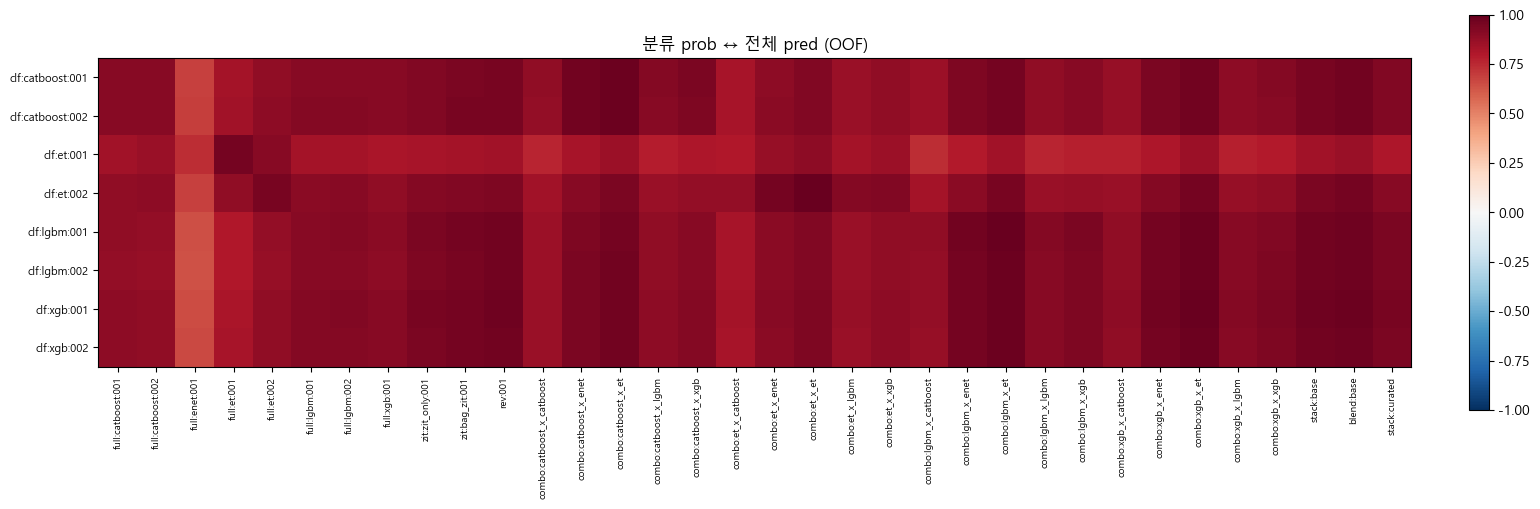

In [7]:
if GROUP_A and GROUP_C:
    Pa, _ = load_group(GROUP_A, 'oof')
    Pc, _ = load_group(GROUP_C, 'oof')
    idx = Pa.index.intersection(Pc.index)
    Pa, Pc = Pa.loc[idx], Pc.loc[idx]
    block = pd.DataFrame({a: Pc.corrwith(Pa[a]) for a in Pa.columns}).T   # 행=분류기, 열=전체모델
    print('=== 분류 prob ↔ 전체 pred — OOF 상관 (행=분류기, 열=전체모델) ===')
    with pd.option_context('display.max_columns', None, 'display.width', 220):
        print(block.round(3).to_string())
    print(f'\n  전체 평균 |corr| = {block.abs().values.mean():.3f}  (min {block.values.min():.3f}, max {block.values.max():.3f})')
    fig, ax = plt.subplots(figsize=(max(6, block.shape[1]*0.4+2), max(3, block.shape[0]*0.5+1)))
    im = ax.imshow(block.values, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(block.shape[1])); ax.set_xticklabels(block.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(block.shape[0])); ax.set_yticklabels(block.index, fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title('분류 prob ↔ 전체 pred (OOF)')
    plt.tight_layout(); plt.show()
else:
    print('그룹 A 또는 C 가 비어 보너스 생략')


## 8. 요약

In [8]:
print('=' * 78)
print(' 예측 상관 요약 (OOF 기준)')
print('=' * 78)
for gname, g in [('A 분류 prob', GROUP_A), ('B 회귀 y>0조건부 pred', GROUP_B), ('C 회귀 전체 pred', GROUP_C)]:
    if not g:
        print(f'  그룹 {gname:24s} : 항목 없음'); continue
    P, y = load_group(g, 'oof')
    v = _offdiag(P.corr())
    print(f'  그룹 {gname:24s} : 항목 {len(g):3d}  ·  상관 mean={v.mean():.3f} median={np.median(v):.3f} [min {v.min():.3f}, max {v.max():.3f}]')
    if gname.startswith('C'):
        rv = _offdiag(P.subtract(y, axis=0).corr())
        print(f'  {"":26s}   잔차 상관 mean={rv.mean():.3f} [min {rv.min():.3f}, max {rv.max():.3f}]  ← 1에 가까울수록 앙상블 이득 적음')
print('=' * 78)
print('해석 가이드:')
print('  · pred 상관 0.95+ 가 대부분이면 "거의 같은 모델" → 앙상블해도 큰 이득 없음')
print('  · 잔차 상관이 0.99+ 면 틀리는 지점까지 똑같음 → 다양성 부족 (다른 패러다임/피처 필요)')
print('  · 상관 낮은 페어(특히 잔차)가 앙상블의 핵심 — 위 pair_extremes 의 ↓ 목록 참고')


 예측 상관 요약 (OOF 기준)
  그룹 A 분류 prob                : 항목   8  ·  상관 mean=0.944 median=0.965 [min 0.834, max 0.995]
  그룹 B 회귀 y>0조건부 pred         : 항목   9  ·  상관 mean=0.510 median=0.443 [min 0.272, max 0.963]
  그룹 C 회귀 전체 pred             : 항목  34  ·  상관 mean=0.889 median=0.903 [min 0.603, max 0.993]
                               잔차 상관 mean=0.996 [min 0.987, max 1.000]  ← 1에 가까울수록 앙상블 이득 적음
해석 가이드:
  · pred 상관 0.95+ 가 대부분이면 "거의 같은 모델" → 앙상블해도 큰 이득 없음
  · 잔차 상관이 0.99+ 면 틀리는 지점까지 똑같음 → 다양성 부족 (다른 패러다임/피처 필요)
  · 상관 낮은 페어(특히 잔차)가 앙상블의 핵심 — 위 pair_extremes 의 ↓ 목록 참고
